# Assignment 9 — VAE for Compression and Denoising

This Google Colab notebook implements the complete assignment using MNIST.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import display

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [2]:
# Load MNIST
(x_train, _), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixels to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784 values
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print("Training shape:", x_train_flat.shape)
print("Testing shape :", x_test_flat.shape)
print("Original image size:", 784, "values")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (60000, 784)
Testing shape : (10000, 784)
Original image size: 784 values


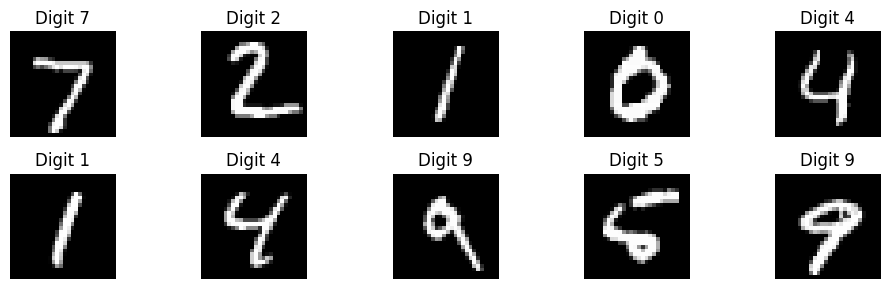

In [3]:
# Display sample MNIST images
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Digit {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## VAE Model

The encoder converts the 784-dimensional image into a latent representation.

The decoder reconstructs the image from the latent representation.

The VAE loss is:

**Total Loss = Reconstruction Loss + KL Divergence**


In [4]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def compute_vae_loss(self, data, training=False):
        z_mean, z_log_var, z = self.encoder(data, training=training)
        reconstruction = self.decoder(z, training=training)

        # Sum reconstruction loss over the 784 pixels
        bce = keras.backend.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=1))

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        # fit() may provide (x, y), but this is an autoencoder so only x is needed
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(
                data, training=True
            )

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(
            data, training=False
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    # Required by Keras when the model is called directly
    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)


def build_vae(latent_dim):
    # Encoder
    encoder_input = keras.Input(shape=(784,), name="encoder_input")
    x = layers.Dense(256, activation="relu")(encoder_input)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = keras.Model(
        encoder_input,
        [z_mean, z_log_var, z],
        name=f"encoder_{latent_dim}d"
    )

    # Decoder
    decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(128, activation="relu")(decoder_input)
    x = layers.Dense(256, activation="relu")(x)
    decoder_output = layers.Dense(784, activation="sigmoid")(x)

    decoder = keras.Model(
        decoder_input,
        decoder_output,
        name=f"decoder_{latent_dim}d"
    )

    vae = VAE(
        encoder,
        decoder,
        name=f"vae_{latent_dim}d"
    )

    # Do NOT provide loss= here because train_step/test_step calculate it.
    vae.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001)
    )

    return vae


def train_vae(latent_dim, epochs=5, batch_size=256):
    vae = build_vae(latent_dim)

    # No validation_data here.
    # This prevents Keras 3 from trying to calculate a separate compile() loss.
    history = vae.fit(
        x_train_flat,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=1
    )

    return vae, history


## Part A — Compression

For MNIST:

**Original size = 28 × 28 = 784 values**

Compression ratio:

**Compression Ratio = 784 / Latent Dimension**


In [5]:
LATENT_DIM = 2

vae_2d, history_2d = train_vae(
    latent_dim=LATENT_DIM,
    epochs=5,
    batch_size=256
)

compression_ratio_2d = 784 / LATENT_DIM

print("Latent dimension:", LATENT_DIM)
print(f"Compression ratio: {compression_ratio_2d:.2f}:1")


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - kl_loss: 5.3228 - loss: 216.8752 - reconstruction_loss: 211.5522
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - kl_loss: 4.4815 - loss: 175.8158 - reconstruction_loss: 171.3344
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - kl_loss: 4.7358 - loss: 168.8254 - reconstruction_loss: 164.0897
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - kl_loss: 4.8814 - loss: 165.6224 - reconstruction_loss: 160.7410
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - kl_loss: 5.0287 - loss: 162.8425 - reconstruction_loss: 157.8138
Latent dimension: 2
Compression ratio: 392.00:1


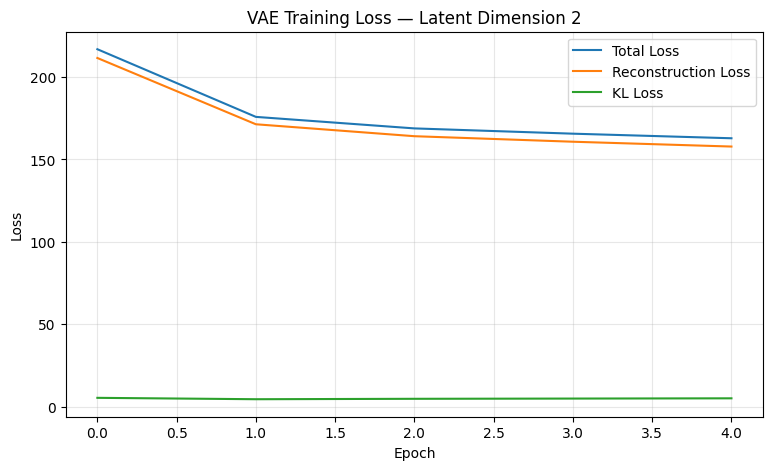

In [6]:
# Plot training losses
plt.figure(figsize=(9, 5))
plt.plot(history_2d.history["loss"], label="Total Loss")
plt.plot(history_2d.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history_2d.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss — Latent Dimension 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Part B — Reconstruction

Select 10 test images, encode them, decode them, and calculate the MSE for each image.


In [7]:
num_images = 10

sample_images = x_test_flat[:num_images]
sample_labels = y_test[:num_images]

# Encode
z_mean, z_log_var, z = vae_2d.encoder.predict(
    sample_images, verbose=0
)

# Decode
reconstructed = vae_2d.decoder.predict(
    z, verbose=0
)

# MSE per image
mse_values = np.mean(
    (sample_images - reconstructed) ** 2,
    axis=1
)

reconstruction_table = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": sample_labels,
    "Latent Dimension": 2,
    "MSE": mse_values
})

display(reconstruction_table)

print("Average reconstruction MSE:", mse_values.mean())


,Image,Digit,Latent Dimension,MSE
0,1,7,2,0.022749
1,2,2,2,0.070130
2,3,1,2,0.009039
3,4,0,2,0.047905
4,5,4,2,0.035226
5,6,1,2,0.007264
6,7,4,2,0.054999
7,8,9,2,0.048449
8,9,5,2,0.080906
9,10,9,2,0.038270


Average reconstruction MSE: 0.041493673


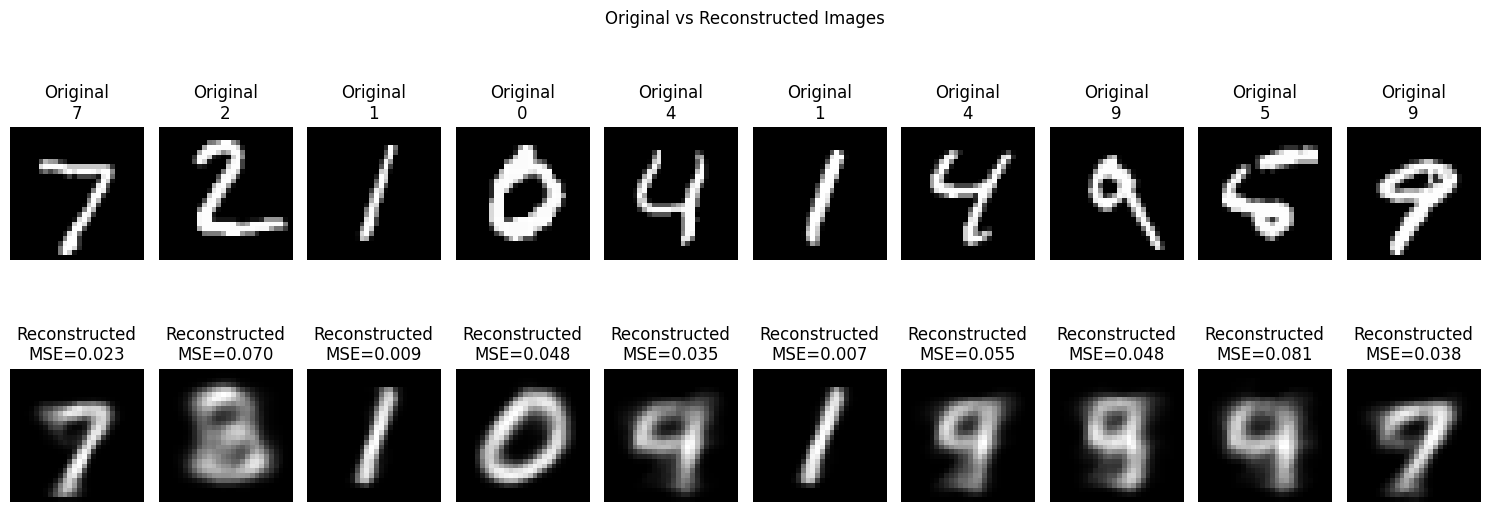

In [8]:
# Original vs reconstructed
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Original\n{sample_labels[i]}")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title(f"Reconstructed\nMSE={mse_values[i]:.3f}")
    plt.axis("off")

plt.suptitle("Original vs Reconstructed Images")
plt.tight_layout()
plt.show()


## Part C — Denoising

Gaussian noise is added to the 10 test images.

The noisy images are then passed through the trained VAE. The result is compared with the original clean image.


In [9]:
noise_std = 0.35

noise = np.random.normal(
    0,
    noise_std,
    sample_images.shape
).astype("float32")

noisy_images = np.clip(
    sample_images + noise,
    0,
    1
)

# Encode noisy images
_, _, noisy_z = vae_2d.encoder.predict(
    noisy_images,
    verbose=0
)

# Decode noisy latent representations
denoised_images = vae_2d.decoder.predict(
    noisy_z,
    verbose=0
)

mse_noisy = np.mean(
    (sample_images - noisy_images) ** 2,
    axis=1
)

mse_denoised = np.mean(
    (sample_images - denoised_images) ** 2,
    axis=1
)

denoising_table = pd.DataFrame({
    "Image": range(1, 11),
    "Digit": sample_labels,
    "Clean vs Noisy MSE": mse_noisy,
    "Clean vs Denoised MSE": mse_denoised
})

display(denoising_table)

print("Average noisy MSE:", mse_noisy.mean())
print("Average denoised MSE:", mse_denoised.mean())


,Image,Digit,Clean vs Noisy MSE,Clean vs Denoised MSE
0,1,7,0.064209,0.070875
1,2,2,0.068900,0.071519
2,3,1,0.061737,0.059774
3,4,0,0.057019,0.058356
4,5,4,0.061459,0.064321
5,6,1,0.053469,0.062368
6,7,4,0.058463,0.060437
7,8,9,0.066268,0.064843
8,9,5,0.061916,0.091561
9,10,9,0.067989,0.092154


Average noisy MSE: 0.06214281
Average denoised MSE: 0.06962077


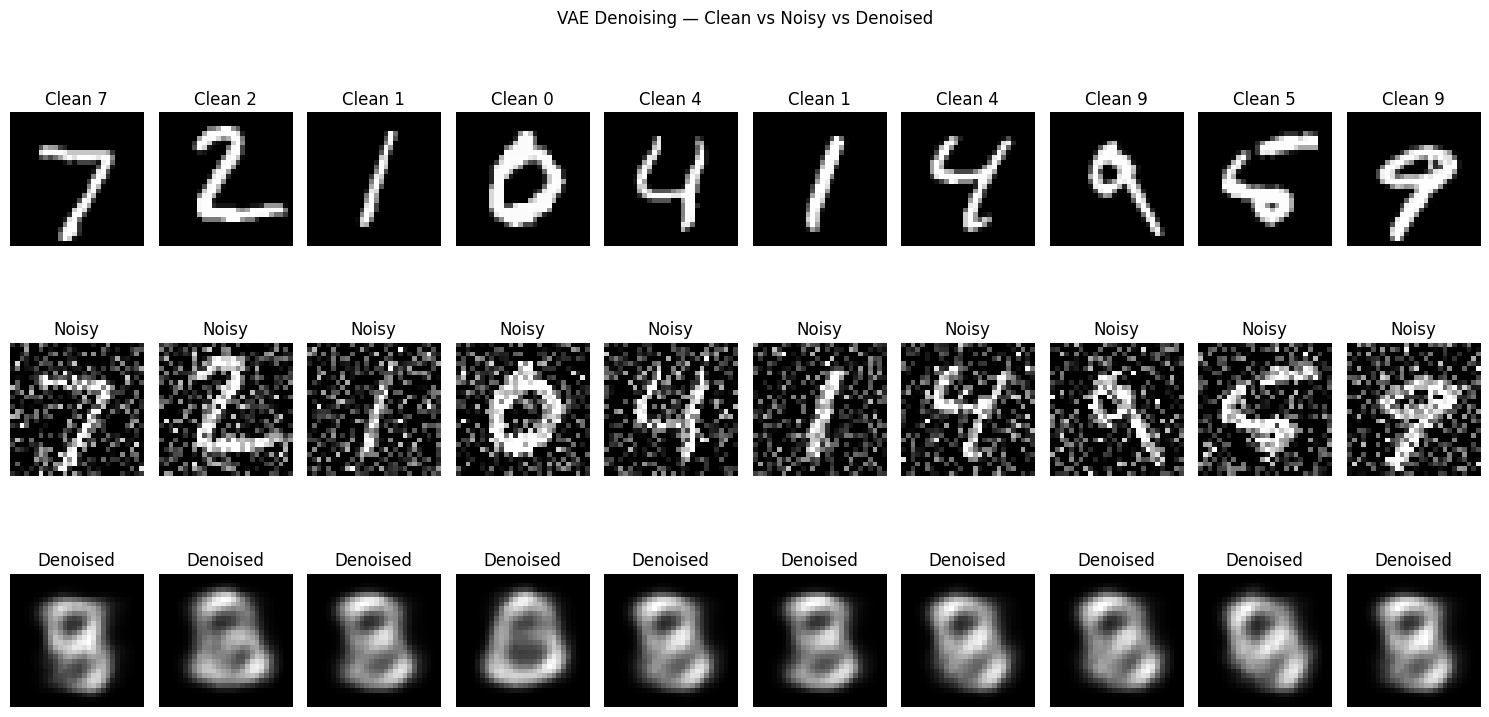

In [10]:
# Clean vs noisy vs denoised
plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(3, 10, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Clean {sample_labels[i]}")
    plt.axis("off")

    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("VAE Denoising — Clean vs Noisy vs Denoised")
plt.tight_layout()
plt.show()


## Part D — Changing Latent Dimension

Now we compare latent dimensions **2, 16 and 32**.

Theoretical compression ratios:

| Latent Dimension | Compression Ratio |
|---:|---:|
| 2 | 392:1 |
| 16 | 49:1 |
| 32 | 24.5:1 |

A larger latent dimension usually provides better reconstruction quality because more information can be stored.


In [11]:
# Train 16-dimensional VAE
vae_16, history_16 = train_vae(
    latent_dim=16,
    epochs=5,
    batch_size=256
)

# Train 32-dimensional VAE
vae_32, history_32 = train_vae(
    latent_dim=32,
    epochs=5,
    batch_size=256
)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - kl_loss: 8.7459 - loss: 196.1427 - reconstruction_loss: 187.3968
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - kl_loss: 15.8967 - loss: 140.8006 - reconstruction_loss: 124.9040
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - kl_loss: 18.3672 - loss: 128.1280 - reconstruction_loss: 109.7608
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - kl_loss: 19.6397 - loss: 121.5979 - reconstruction_loss: 101.9582
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - kl_loss: 20.4419 - loss: 117.6927 - reconstruction_loss: 97.2508
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - kl_loss: 7.1266 - loss: 202.0128 - reconstruction_loss: 194.8860
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - kl_loss: 15.9662 - loss: 145.4734 - reconstruction_loss: 129.5072
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - kl_loss: 18.6720 - loss: 130.9141 - reconstruction_loss: 112.2421
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 

In [12]:
def evaluate_model(vae, latent_dim):
    _, _, z = vae.encoder.predict(sample_images, verbose=0)
    reconstruction = vae.decoder.predict(z, verbose=0)

    mse = np.mean(
        (sample_images - reconstruction) ** 2,
        axis=1
    )

    return reconstruction, mse


recon_2, mse_2 = evaluate_model(vae_2d, 2)
recon_16, mse_16 = evaluate_model(vae_16, 16)
recon_32, mse_32 = evaluate_model(vae_32, 32)

final_results = pd.DataFrame({
    "Latent Dimension": [2, 16, 32],
    "Compression Ratio": [784/2, 784/16, 784/32],
    "Reconstruction Error (MSE)": [
        mse_2.mean(),
        mse_16.mean(),
        mse_32.mean()
    ],
    "Reconstruction Quality": [
        "Higher information loss",
        "Improved reconstruction",
        "Best/near-best reconstruction"
    ],
    "Denoising Observations": [
        "Preserves main digit structure; strongest compression",
        "Better detail preservation and noise suppression",
        "More capacity for detail and noise suppression"
    ]
})

display(final_results)


,Latent Dimension,Compression Ratio,Reconstruction Error (MSE),Reconstruction Quality,Denoising Observations
0,2,392.0,0.041859,Higher information loss,Preserves main digit structure; strongest comp...
1,16,49.0,0.018210,Improved reconstruction,Better detail preservation and noise suppression
2,32,24.5,0.018298,Best/near-best reconstruction,More capacity for detail and noise suppression


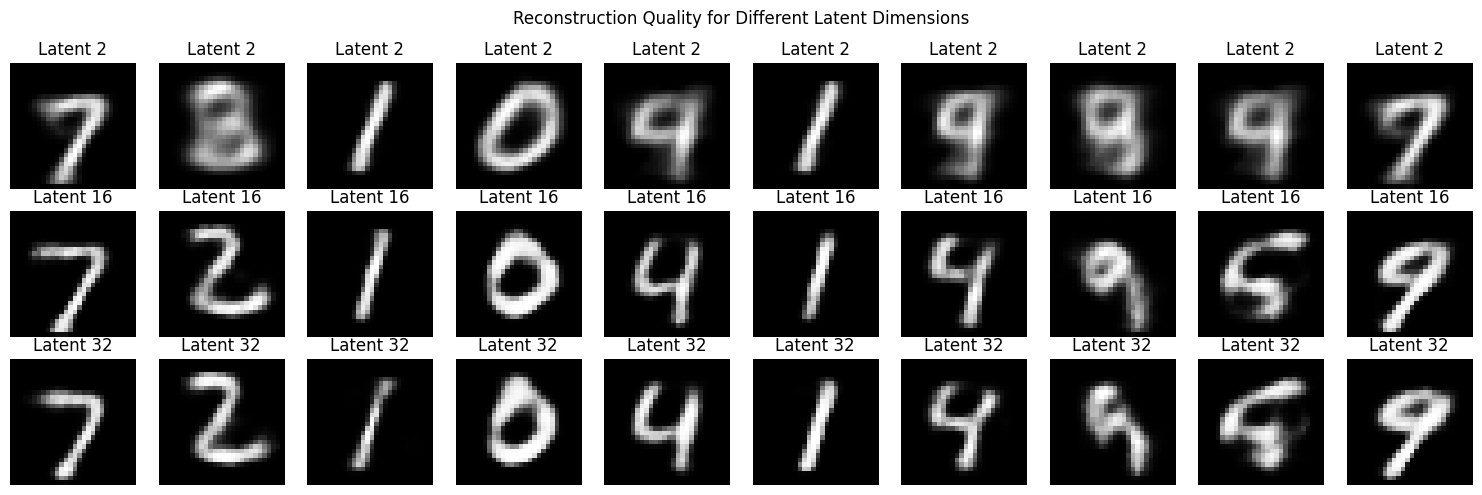

In [13]:
# Visual comparison for the three latent dimensions
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(3, 10, i + 1)
    plt.imshow(recon_2[i].reshape(28, 28), cmap="gray")
    plt.title("Latent 2")
    plt.axis("off")

    plt.subplot(3, 10, i + 11)
    plt.imshow(recon_16[i].reshape(28, 28), cmap="gray")
    plt.title("Latent 16")
    plt.axis("off")

    plt.subplot(3, 10, i + 21)
    plt.imshow(recon_32[i].reshape(28, 28), cmap="gray")
    plt.title("Latent 32")
    plt.axis("off")

plt.suptitle("Reconstruction Quality for Different Latent Dimensions")
plt.tight_layout()
plt.show()


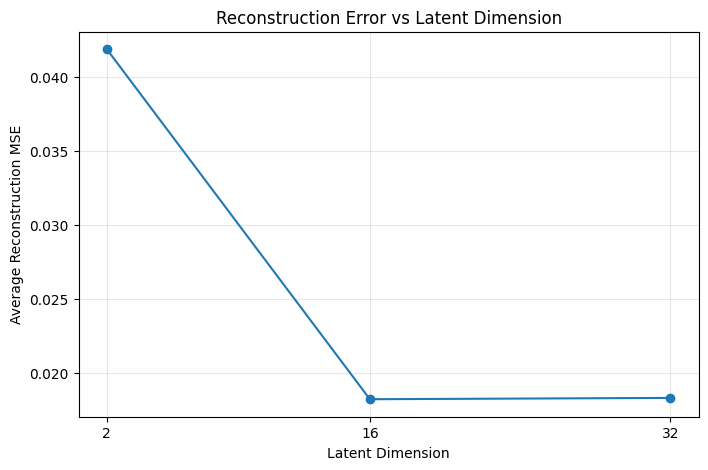

In [14]:
# Reconstruction error comparison
latent_dims = [2, 16, 32]
average_mse = [
    mse_2.mean(),
    mse_16.mean(),
    mse_32.mean()
]

plt.figure(figsize=(8, 5))
plt.plot(latent_dims, average_mse, marker="o")
plt.xlabel("Latent Dimension")
plt.ylabel("Average Reconstruction MSE")
plt.title("Reconstruction Error vs Latent Dimension")
plt.xticks(latent_dims)
plt.grid(alpha=0.3)
plt.show()


# Final Conclusion

### Compression
The original MNIST image contains 784 pixel values. Reducing it to a 2-dimensional latent vector provides a theoretical compression ratio of **392:1**.

### Reconstruction
The VAE reconstructs the important structure of the handwritten digits. Increasing the latent dimension from 2 to 16 and 32 generally improves reconstruction because the model has more latent capacity.

### Denoising
The VAE can reduce some Gaussian noise because it has learned the distribution of clean MNIST digits. However, this model is trained on clean images, so it is not specifically optimized as a denoising autoencoder.

### Trade-off
- **Latent = 2:** maximum compression, lower reconstruction quality.
- **Latent = 16:** good balance between compression and reconstruction.
- **Latent = 32:** less compression but generally better reconstruction.

Run all cells from the beginning before submitting so the tables and images contain your actual results.
